In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [7]:
df[df.Age.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [9]:
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [10]:
test_df['Age'] = test_df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df['Age'].isnull().sum()

np.int64(0)

In [12]:
test_df['Age'].isnull().sum()

np.int64(0)

In [13]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [14]:
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [15]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [16]:
test_df['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [17]:
df['Title'] = df['Title'].replace(['Mlle'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
df['Title'] = df['Title'].replace(['Ms'], 'Miss')
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don','Dr', 'Major', 'Rev', 'Sir', 'Jonkheer']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')


In [20]:
test_df['Title'] = test_df['Title'].replace(['Mlle'], 'Miss')
test_df['Title'] = test_df['Title'].replace(['Mme'], 'Mrs')
test_df['Title'] = test_df['Title'].replace(['Ms'], 'Miss')
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Dona','Dr', 'Major', 'Rev', 'Sir', 'Jonkheer']

test_df['Title'] = test_df['Title'].replace(rare_titles, 'Rare')


In [21]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [22]:
test_df['Title'].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

In [23]:
df.drop('Name', axis=1, inplace=True)

In [24]:
test_df.drop('Name', axis=1, inplace=True)

In [25]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)

C:\Users\muska\AppData\Local\Temp\ipykernel_23620\1718695086.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)


In [26]:
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0],inplace = True)

C:\Users\muska\AppData\Local\Temp\ipykernel_23620\2586518244.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Embarked'].fillna(test_df['Embarked'].mode()[0],inplace = True)


In [28]:
test_df.Embarked.isnull().sum()

np.int64(0)

In [29]:
test_df.Embarked.isnull().sum()

np.int64(0)

In [33]:
df.drop('Cabin', axis=1, inplace=True)

In [34]:
test_df.drop('Cabin', axis=1, inplace=True)

In [35]:
df.drop('Ticket', axis=1, inplace=True)

In [ ]:
test_df.drop('Ticket', axis=1, inplace=True)

In [40]:
passenger_id = test_df['PassengerId']

In [41]:
df.drop('PassengerId', axis = 1 , inplace = True)

In [44]:
test_df.drop('PassengerId', axis = 1 , inplace = True)

In [47]:
test_df['Fare'] = test_df.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

In [48]:
print(test_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    float64
 6   Embarked  418 non-null    object 
 7   Title     418 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 26.3+ KB
None


In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
 8   Title     891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB
None


In [50]:
df_len = len(df)

combined = pd.concat([df, test_df], axis=0)

combined = pd.get_dummies(
    combined,
    columns=['Embarked', 'Title', 'Sex'],
    drop_first=True
)   

bool_cols = combined.select_dtypes(include='bool').columns
combined[bool_cols] = combined[bool_cols].astype(int)

df = combined.iloc[:df_len]
test_df = combined.iloc[df_len:]

In [52]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_male
0,0.0,3,22.0,1,0,7.2500,0,1,0,1,0,0,1
1,1.0,1,38.0,1,0,71.2833,0,0,0,0,1,0,0
2,1.0,3,26.0,0,0,7.9250,0,1,1,0,0,0,0
3,1.0,1,35.0,1,0,53.1000,0,1,0,0,1,0,0
4,0.0,3,35.0,0,0,8.0500,0,1,0,1,0,0,1


In [53]:
test_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_male
0,NaN,3,34.5,0,0,7.8292,1,0,0,1,0,0,1
1,NaN,3,47.0,1,0,7.0000,0,1,0,0,1,0,0
2,NaN,2,62.0,0,0,9.6875,1,0,0,1,0,0,1
3,NaN,3,27.0,0,0,8.6625,0,1,0,1,0,0,1
4,NaN,3,22.0,1,1,12.2875,0,1,0,0,1,0,0


In [54]:
X = df.drop('Survived',axis = 1)
y = df['Survived']


In [55]:
print(X.shape)
print(y.shape)

(891, 12)
(891,)


In [56]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(X,y , test_size = 0.2, random_state= 42)

In [57]:
print(X_train.shape)
print(y_train.shape)

(712, 12)
(712,)


In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion='gini', max_depth= 4, random_state= 52)
clf.fit(X_train , y_train)

DecisionTreeClassifier(max_depth=4, random_state=52)

In [62]:
y_pred = clf.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred))

Accuracy:  0.8324022346368715


In [63]:
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.8426966292134831
Test Accuracy: 0.8324022346368715


In [65]:
# for depth in range(1,11):
#     clf = DecisionTreeClassifier(criterion='gini', max_depth= depth, random_state= 52)
#     clf.fit(X_train , y_train)

#     train_acc = accuracy_score(y_train, clf.predict(X_train))
#     test_acc = accuracy_score(y_test, clf.predict(X_test))

#     print(f"Depth={depth} | Train={train_acc:.4f} | Test={test_acc:.4f}")

## Random Forest 

In [66]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(criterion='entropy' ,max_depth = 11,n_estimators=100,max_features='sqrt', random_state=52 )
rfc.fit(X_train , y_train )

RandomForestClassifier(criterion='entropy', max_depth=11, random_state=52)

In [67]:
y_pred = rfc.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred))

Accuracy:  0.8435754189944135


[[93 12]
 [16 58]]


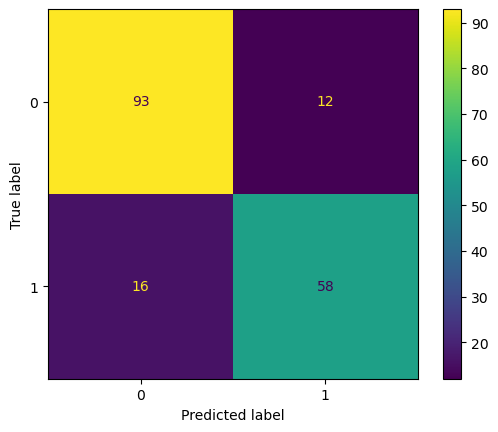

In [83]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
print(cm)

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87       105
         1.0       0.83      0.78      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179



In [77]:
train_acc = rfc.score(X_train, y_train)
test_acc = rfc.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.9410112359550562
Test Accuracy : 0.8435754189944135


In [79]:
from sklearn.metrics import roc_auc_score

y_prob = rfc.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc)

ROC AUC: 0.8928571428571428


In [81]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rfc, X, y, cv=5)

print(scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

[0.82122905 0.80337079 0.86516854 0.7752809  0.83707865]
Mean Accuracy: 0.8204255853367648
Standard Deviation: 0.030360536835788553


In [68]:
# for depth in range(1, 15):
#     rfc = RandomForestClassifier(n_estimators=100,criterion='entropy' ,max_depth=depth,random_state=52,max_features='sqrt')
#     rfc.fit(X_train , y_train )
    
#     train_acc = accuracy_score(y_train, rfc.predict(X_train))
#     test_acc = accuracy_score(y_test, rfc.predict(X_test))

#     print(f"Depth={depth} | Train={train_acc:.4f} | Test={test_acc:.4f}")
    

In [89]:
print(X.columns.equals(test_df.columns))

True


In [90]:
print(X.shape)
print(test_df.shape)

(891, 12)
(418, 12)


In [91]:
print(test_df.isnull().sum().sum())

0


In [84]:
prediction = rfc.predict(test_df)

In [85]:
prediction

array([0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 0.

In [86]:
submission = pd.DataFrame({
    'PassengerId': passenger_id,
    'Survived': prediction
})

In [93]:
print(submission.dtypes)

PassengerId      int64
Survived       float64
dtype: object


In [94]:
submission['Survived'] = submission['Survived'].astype(int)

In [95]:
submission.to_csv("submission.csv", index=False)